# **Bioinformatics Project | Computational Drug Discovery | Part 2**

In **Part 2**, we will be performing Descriptor Calculation and Exploratory Data Analysis.

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

ImportError: numpy.core._multiarray_umath failed to import

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

In [2]:
df = pd.read_csv('Data/acetylcholinesterase_01_bioactivity_data_curated.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.00,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.00,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.00,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.00,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.00,active
...,...,...,...,...
7170,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,0.48,active
7171,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,400.00,active
7172,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,11.10,active
7173,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,52.00,active


## Calculation of Descriptors

Descriptors are the calculated physicochemical and structural properties of small molecules. They transform raw chemical information into numerical values. To know more see `Knowledge_Base.md`

**FACT**\
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10 

In [3]:
def descriptors(smiles):

    moldata = []
    for elm in smiles:
        mol = Chem.MolFromSmiles(elm) #RDKit converts smiles into a molecular object.
        moldata.append(mol) 
    
    baseData = []
    # Take every molecular object and find different descriptors.
    for mol in moldata: 
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        baseData.append([desc_MolWt, desc_MolLogP, desc_NumHDonors, desc_NumHAcceptors])
    
    columnNames = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]
    descriptors = pd.DataFrame(data= baseData, columns= columnNames)

    return descriptors

In [4]:
df_desc = descriptors(df.canonical_smiles)
df_desc

,MW,LogP,NumHDonors,NumHAcceptors
0,312.325,2.80320,0,6
1,376.913,4.55460,0,5
2,426.851,5.35740,0,5
3,404.845,4.70690,0,5
4,346.334,3.09530,0,6
...,...,...,...,...
7170,449.295,7.04910,0,3
7171,356.816,2.94110,3,5
7172,414.465,3.03242,3,6
7173,415.324,4.65730,2,4


Now let's combine the dataframes

In [5]:
df_combined = pd.concat([df, df_desc], axis= 1)
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.00,active,312.325,2.80320,0,6
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.00,active,376.913,4.55460,0,5
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.00,inactive,426.851,5.35740,0,5
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.00,active,404.845,4.70690,0,5
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.00,active,346.334,3.09530,0,6
...,...,...,...,...,...,...,...,...
7170,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,0.48,active,449.295,7.04910,0,3
7171,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,400.00,active,356.816,2.94110,3,5
7172,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,11.10,active,414.465,3.03242,3,6
7173,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,52.00,active,415.324,4.65730,2,4


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**. Also this makes the values more intuitive as in, higher pIC50 means the drug is more potent or strongly inhibits acetylcholinesterase opposite to what we see in IC50.

This custom function pIC50() will accept a DataFrame as input and will:
* Cap the value of IC50 to 100,000,000, else after conversion the final value would be negative
* Take the IC50 values from the `standard_value` column and converts it from nM to M by multiplying the value by 10<sup>-9</sup>
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [6]:
# Note the spread of IC50 before conversion
df_combined.standard_value.describe()

count    7.175000e+03
mean     1.225867e+05
std      2.131348e+06
min      0.000000e+00
25%      1.587450e+02
50%      2.410000e+03
75%      1.644000e+04
max      1.636817e+08
Name: standard_value, dtype: float64

In [7]:
def make_pIC50(IC_Series):
    
    pIC_val = []
    for IC_nM in IC_Series:
        if IC_nM > 100000000:
            IC_nM = 100000000
        IC_M = IC_nM * (10**-9) # Convert nM to M
        pIC_val.append(-np.log10(IC_M))
    
    return pd.Series(pIC_val, name= "pIC50")

Actually there is a row where `standard_value` = 0 which does not make any sense. We need to remove it as it will create a runtimewarning: divide by zero

In [8]:
df_combined = df_combined[df_combined['standard_value'] > 0].copy()
df_combined.reset_index(drop= True, inplace= True)

In [9]:
df_without_IC = df_combined.drop('standard_value', axis= 1)
df_pIC = make_pIC50(df_combined.standard_value)

In [10]:
df_converted = pd.concat([df_without_IC, df_pIC], axis= 1)
df_converted

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.80320,0,6,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.55460,0,5,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.35740,0,5,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.70690,0,5,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.09530,0,6,6.096910
...,...,...,...,...,...,...,...,...
7169,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,active,449.295,7.04910,0,3,9.318759
7170,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,active,356.816,2.94110,3,5,6.397940
7171,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,active,414.465,3.03242,3,6,7.954677
7172,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,active,415.324,4.65730,2,4,7.283997


In [11]:
# Notice the spread of pIC50 after conversion
df_converted.pIC50.describe()

count    7174.000000
mean        5.815051
std         1.549445
min         1.000000
25%         4.783571
50%         5.617084
75%         6.798603
max        14.301030
Name: pIC50, dtype: float64

In [12]:
df_converted.to_csv('Data/acetylcholinesterase_02_bioactivity_data_3class_pIC50.csv', index = False)

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the `intermediate` class from our data set so that we can compare the `active` and `inactive` class well.

In [14]:
df_2class = df_converted[df_converted['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.80320,0,6,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.55460,0,5,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.35740,0,5,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.70690,0,5,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.09530,0,6,6.096910
...,...,...,...,...,...,...,...,...
7169,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,active,449.295,7.04910,0,3,9.318759
7170,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,active,356.816,2.94110,3,5,6.397940
7171,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,active,414.465,3.03242,3,6,7.954677
7172,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,active,415.324,4.65730,2,4,7.283997


### **EDA in this field is also called Chemical Space Analysis**

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

c:\Python 3.8.0\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


**Frequency plot for 2 bioactivity class**

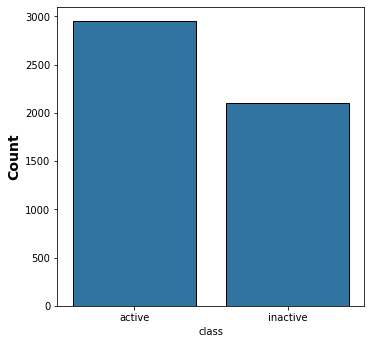

In [17]:
plt.figure(figsize= (5.5,5.5))

sns.countplot(x= 'class', data= df_2class, edgecolor= 'black')

plt.ylabel("Bioactivity class", fontsize= 14, fontweight= 'bold')
plt.ylabel("Count", fontsize= 14, fontweight= 'bold')

plt.show()

**Scatter plot for MW vs logP**

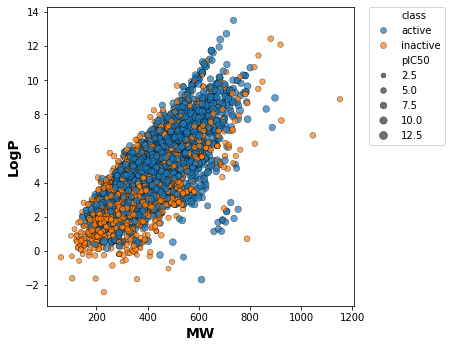

In [18]:
plt.figure(figsize=(5.5,5.5))

sns.scatterplot(x= 'MW', y= 'LogP', data= df_2class, hue= 'class', size= 'pIC50', edgecolor= 'black', alpha= 0.7)

plt.xlabel('MW', fontsize= 14, fontweight= 'bold')
plt.ylabel('LogP', fontsize= 14, fontweight= 'bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

plt.show()

**Observations**

- 2 bioactivity classes are spanning similar chemical spaces
- Larger molecules tend to be more hydrophobic. This is common because larger molecules often contain more carbon-rich regions.
- Blue is mixed with orange almost everywhere. Which means MW and LogP by themselves are not enough to determine whether a molecule is active.
- The larger bubbles (higher potency) are scattered around. There isn't a single obvious hotspot, suggesting that activity depends on detailed molecular structure, not just these four Lipinski descriptors.

### Box Plots

**pIC50 Values**

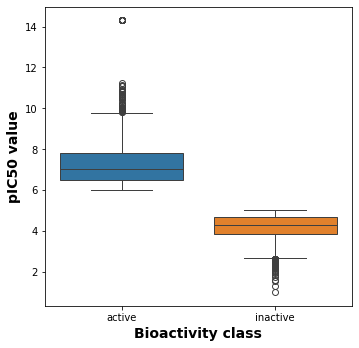

In [20]:
plt.figure(figsize= (5.5,5.5))

sns.boxplot(x= 'class', y= 'pIC50', data= df_2class, hue= 'class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.show()

But we need to verify the statistical significance of the data. Let's do `Mann-Whitney U` test for this. The reason for choosing this test is:

- Non-parametric
- Distribution-free (MW, LogP can often be skewed)
- Robust for biological data

In [21]:
from scipy.stats import mannwhitneyu

def mannwhitneyutest(descriptor):
    # Segregate classes
    active = df_2class[df_2class['class'] == 'active'][descriptor]
    inactive = df_2class[df_2class['class'] == 'inactive'][descriptor]

    #test
    stat, p = mannwhitneyu(active, inactive)

    #interpret
    alpha = 0.05
    if p > alpha:
        intpr = 'Same distribution, fail to reject H0'
    else:
        intpr = 'Significantly different distribution, reject H0'
    
    results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':intpr}, index=[0])

    return results

In [22]:
mannwhitneyutest('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,0.0,0.0,0.05,"Significantly different distribution, reject H0"


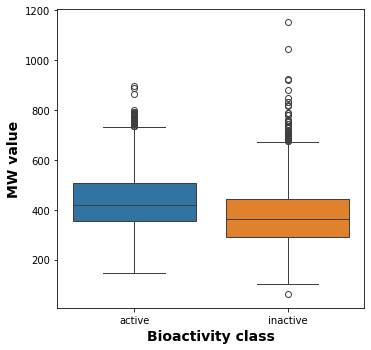

In [26]:
plt.figure(figsize= (5.5,5.5))

sns.boxplot(x= 'class', y= 'MW', data= df_2class, hue= 'class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW value', fontsize=14, fontweight='bold')

plt.show()

In [24]:
mannwhitneyutest('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,2196507.0,9.593733e-70,0.05,"Significantly different distribution, reject H0"


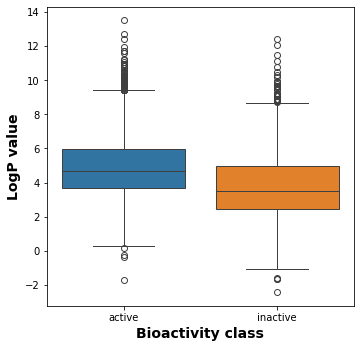

In [27]:
plt.figure(figsize= (5.5,5.5))

sns.boxplot(x= 'class', y= 'LogP', data= df_2class, hue= 'class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP value', fontsize=14, fontweight='bold')

plt.show()

In [28]:
mannwhitneyutest('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,2010469.0,1.365969e-100,0.05,"Significantly different distribution, reject H0"


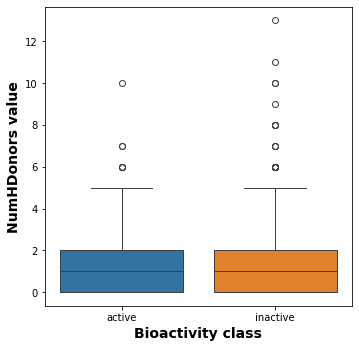

In [29]:
plt.figure(figsize= (5.5,5.5))

sns.boxplot(x= 'class', y= 'NumHDonors', data= df_2class, hue= 'class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors value', fontsize=14, fontweight='bold')

plt.show()

In [30]:
mannwhitneyutest('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,2823315.0,1.175671e-08,0.05,"Significantly different distribution, reject H0"


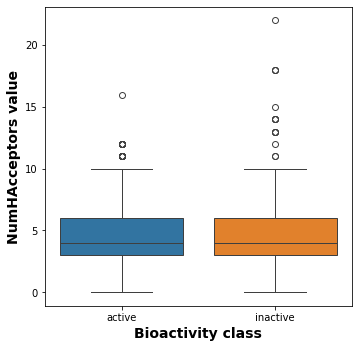

In [31]:
plt.figure(figsize= (5.5,5.5))

sns.boxplot(x= 'class', y= 'NumHAcceptors', data= df_2class, hue= 'class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors value', fontsize=14, fontweight='bold')

plt.show()

In [32]:
mannwhitneyutest('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,2961275.0,0.003756,0.05,"Significantly different distribution, reject H0"


All of the 4 Lipinski's descriptors exhibited ***statistically significant difference*** between the **actives** and **inactives**.